# Evaluierung des MixUp-Metrik-Modells auf TextComplexityDE (Naderi et al., 2019)

Dieses Notebook evaluiert das trainierte **MixUp-Regressormodell** auf dem Benchmark **TextComplexityDE** (1.000 deutsche Wikipedia-Sätze mit menschlichen Urteilen von Deutschlernenden).

In [7]:
import os
import sys
import json
import urllib.request
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def find_repo_root():
    p = os.path.abspath(os.getcwd())
    while p != os.path.dirname(p):
        if os.path.exists(os.path.join(p, "data")) and os.path.exists(os.path.join(p, "results")):
            return p
        p = os.path.dirname(p)
    return os.path.abspath(os.path.expanduser("~/Documents/Master Thesis"))

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print("Arbeitsverzeichnis:", os.getcwd())

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "figure.dpi": 150
})


Arbeitsverzeichnis: /Users/fietescheel/Documents/Master Thesis


## 1. TextComplexityDE Benchmark-Daten laden

Einlesen der vorberechneten Modellvorhersagen auf den 1.000 Wikipedia-Sätzen.

In [8]:
CSV_PATH = os.path.join(REPO_ROOT, "results/evaluation/textcomplexityde_eval.csv")

if not os.path.exists(CSV_PATH):
    print(f"[FEHLER] {CSV_PATH} nicht gefunden.")
else:
    df_tc = pd.read_csv(CSV_PATH)
    print(f"Ergebnisse erfolgreich geladen: {len(df_tc)} Zeilen aus {CSV_PATH}")
    display(df_tc.head())


Ergebnisse erfolgreich geladen: 1000 Zeilen aus /Users/fietescheel/Documents/Master Thesis/results/evaluation/textcomplexityde_eval.csv


,Sentence,MOS_Complexity,MOS_Understandability,MOS_Lexical_difficulty,Human_Simplicity_Norm,pred_simplicity
0,"1878 wurde die Insel Zypern besetzt, als Reakt...",2.363636,1.222222,1.777778,0.744318,0.610347
1,1884 begann er mit dem Violinspiel und erhielt...,1.600000,1.000000,1.125000,0.887500,0.586926
2,1887 gelang Berliner der entscheidende Durchbr...,2.222222,1.700000,3.000000,0.770833,0.569140
3,1893 kam er doch noch als Kadett nach Sandhurs...,3.500000,3.400000,3.800000,0.531250,0.609143
4,1915 publizierte er die allgemeine Relativität...,1.333333,1.000000,1.636364,0.937500,0.348917


## 2. Statistische Korrelationen & Performanz-Metriken

In [9]:
preds = df_tc["pred_simplicity"]

# Korrelationen
r_comp, p_r_comp = pearsonr(preds, df_tc["MOS_Complexity"])
rho_comp, p_rho_comp = spearmanr(preds, df_tc["MOS_Complexity"])
tau_comp, _ = kendalltau(preds, df_tc["MOS_Complexity"])

rho_und, _ = spearmanr(preds, df_tc["MOS_Understandability"])
rho_lex, _ = spearmanr(preds, df_tc["MOS_Lexical_difficulty"])

# Fehlermaße
mae = mean_absolute_error(df_tc["Human_Simplicity_Norm"], preds)
mse = mean_squared_error(df_tc["Human_Simplicity_Norm"], preds)
r2 = r2_score(df_tc["Human_Simplicity_Norm"], preds)

summary_data = {
    "Metrik": [
        "Pearson r (vs. MOS Komplexität)",
        "Spearman rho (vs. MOS Komplexität)",
        "Kendall tau (vs. MOS Komplexität)",
        "Spearman rho (vs. MOS Verständlichkeit)",
        "Spearman rho (vs. MOS Lexikalische Schwierigkeit)",
        "MAE (auf normalisierter Einfachheit)",
        "MSE (auf normalisierter Einfachheit)",
        "R² Score (auf normalisierter Einfachheit)"
    ],
    "Wert": [
        r_comp,
        rho_comp,
        tau_comp,
        rho_und,
        rho_lex,
        mae,
        mse,
        r2
    ]
}

res_df = pd.DataFrame(summary_data)
display(res_df.style.format({"Wert": "{:.4f}"}))


,Metrik,Wert
0,Pearson r (vs. MOS Komplexität),-0.8070
1,Spearman rho (vs. MOS Komplexität),-0.7928
2,Kendall tau (vs. MOS Komplexität),-0.6041
3,Spearman rho (vs. MOS Verständlichkeit),-0.6997
4,Spearman rho (vs. MOS Lexikalische Schwierigkeit),-0.7425
5,MAE (auf normalisierter Einfachheit),0.2166
6,MSE (auf normalisierter Einfachheit),0.0625
7,R² Score (auf normalisierter Einfachheit),-0.2760


## 3. Visualisierungen

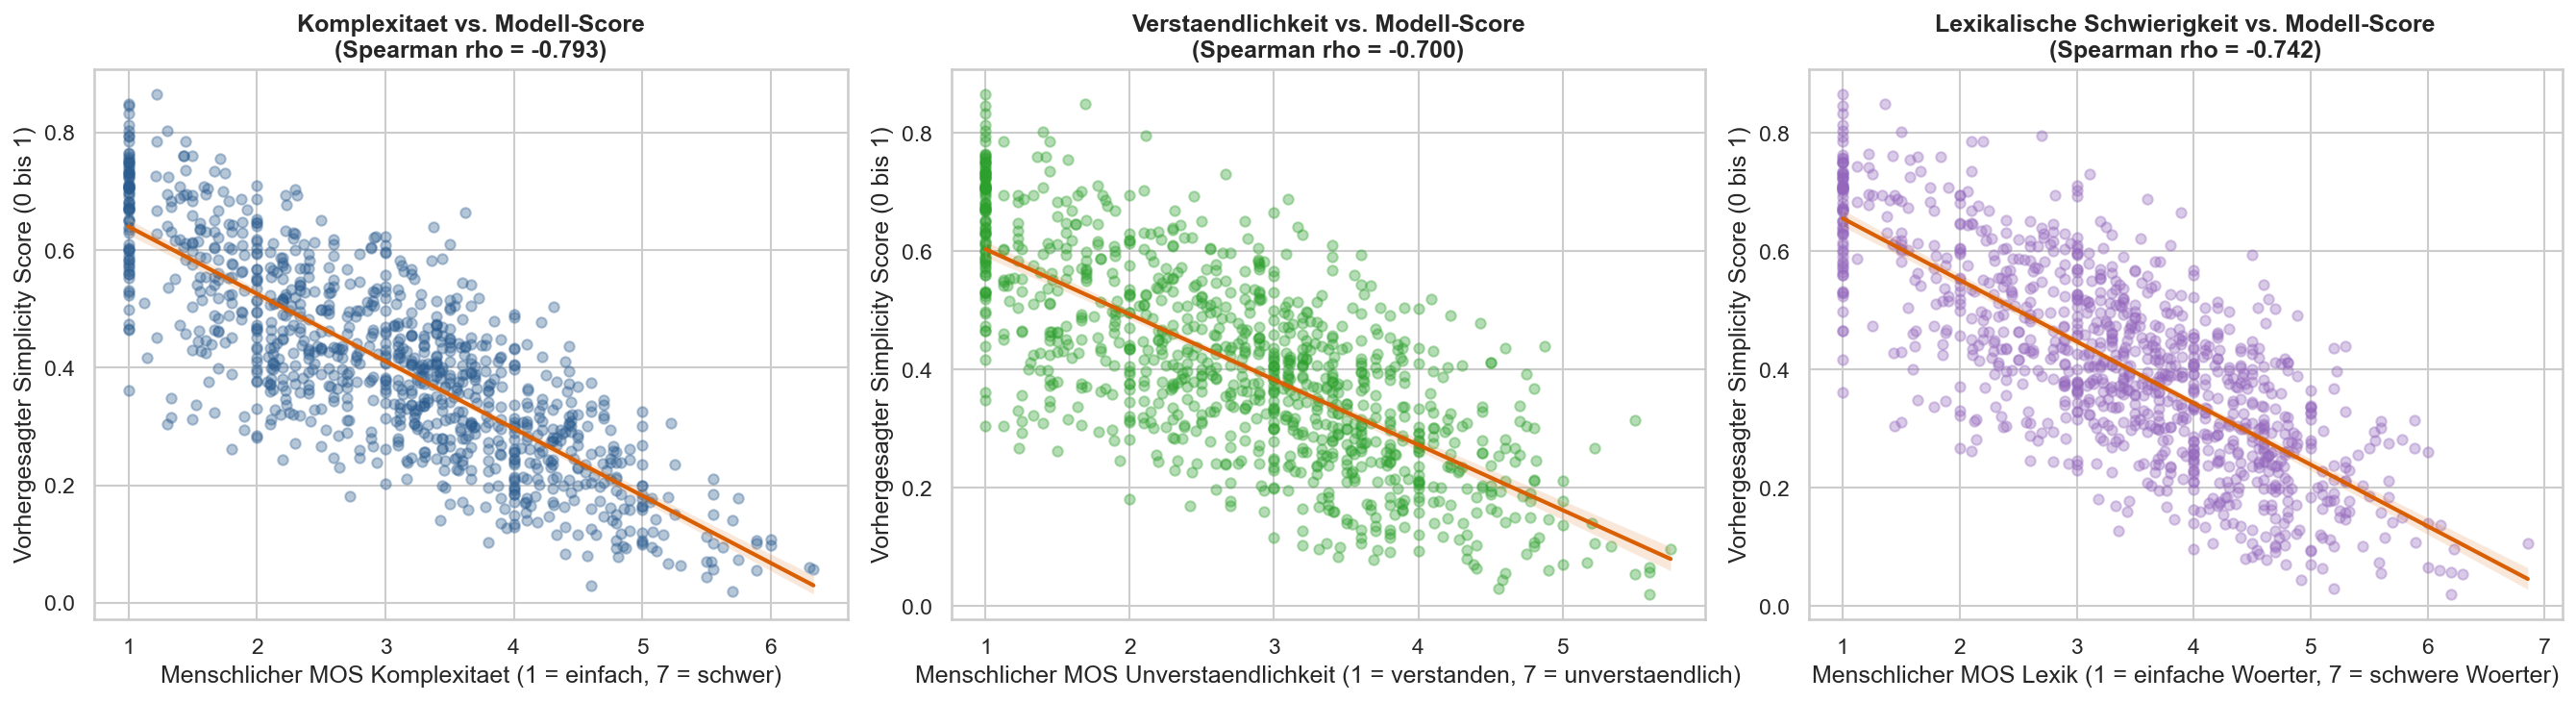

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Complexity
sns.regplot(
    data=df_tc, x="MOS_Complexity", y="pred_simplicity",
    ax=axes[0], color="#2b5c8f", scatter_kws={"alpha": 0.35, "s": 25}, line_kws={"color": "#d95f02", "lw": 2}
)
axes[0].set_title(f"Komplexitaet vs. Modell-Score\n(Spearman rho = {rho_comp:.3f})", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Menschlicher MOS Komplexitaet (1 = einfach, 7 = schwer)")
axes[0].set_ylabel("Vorhergesagter Simplicity Score (0 bis 1)")

# Understandability
sns.regplot(
    data=df_tc, x="MOS_Understandability", y="pred_simplicity",
    ax=axes[1], color="#2ca02c", scatter_kws={"alpha": 0.35, "s": 25}, line_kws={"color": "#d95f02", "lw": 2}
)
axes[1].set_title(f"Verstaendlichkeit vs. Modell-Score\n(Spearman rho = {rho_und:.3f})", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Menschlicher MOS Unverstaendlichkeit (1 = verstanden, 7 = unverstaendlich)")
axes[1].set_ylabel("Vorhergesagter Simplicity Score (0 bis 1)")

# Lexical Difficulty
sns.regplot(
    data=df_tc, x="MOS_Lexical_difficulty", y="pred_simplicity",
    ax=axes[2], color="#9467bd", scatter_kws={"alpha": 0.35, "s": 25}, line_kws={"color": "#d95f02", "lw": 2}
)
axes[2].set_title(f"Lexikalische Schwierigkeit vs. Modell-Score\n(Spearman rho = {rho_lex:.3f})", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Menschlicher MOS Lexik (1 = einfache Woerter, 7 = schwere Woerter)")
axes[2].set_ylabel("Vorhergesagter Simplicity Score (0 bis 1)")

plt.tight_layout()
os.makedirs("results/plots", exist_ok=True)
plt.savefig("results/plots/textcomplexityde_mixup_scatter_3panel.png", bbox_inches="tight", dpi=300)
plt.show()


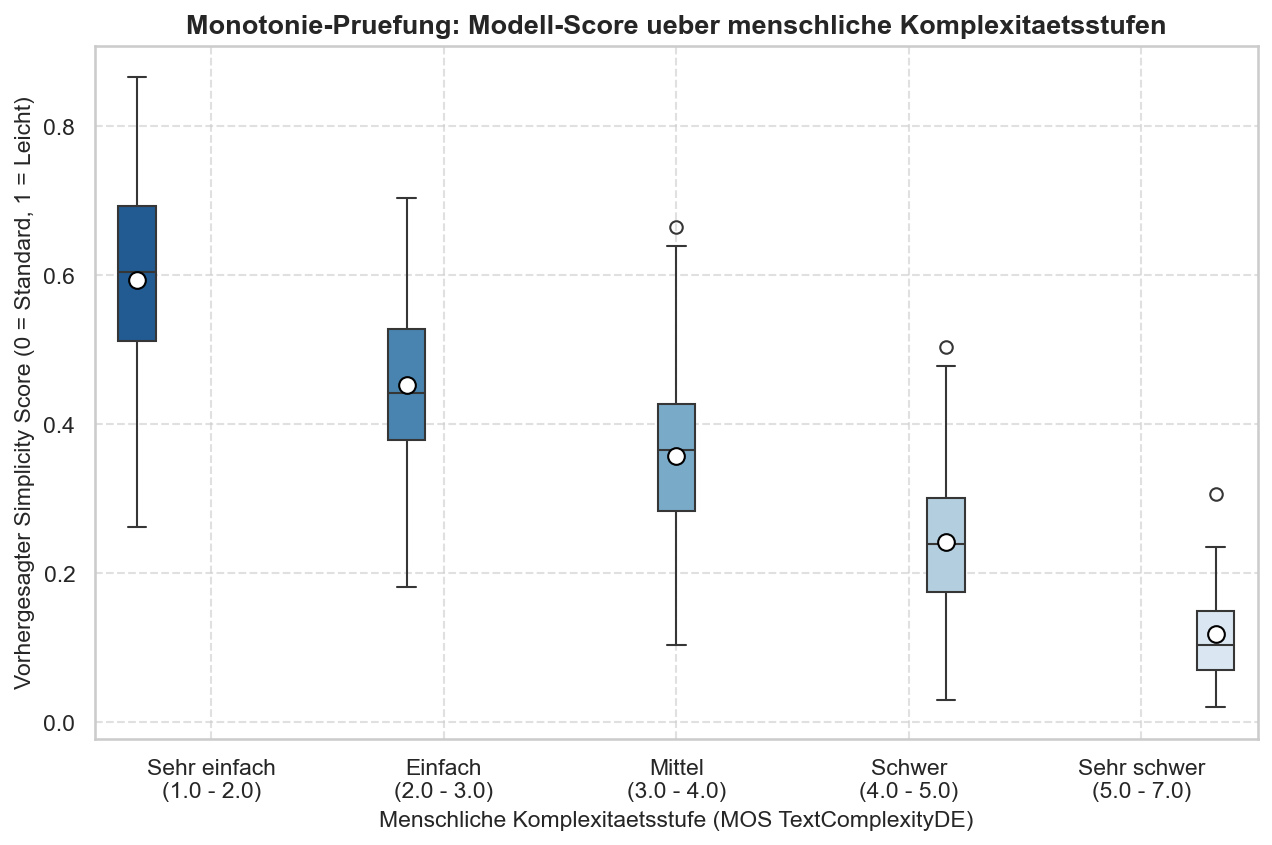

In [11]:
# Boxplots nach Komplexitäts-Intervallen
bins = [1.0, 2.0, 3.0, 4.0, 5.0, 7.0]
labels = ["Sehr einfach\n(1.0 - 2.0)", "Einfach\n(2.0 - 3.0)", "Mittel\n(3.0 - 4.0)", "Schwer\n(4.0 - 5.0)", "Sehr schwer\n(5.0 - 7.0)"]
df_tc["Complexity_Category"] = pd.cut(df_tc["MOS_Complexity"], bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_tc, x="Complexity_Category", y="pred_simplicity",
    palette="Blues_r", hue="Complexity_Category", legend=False, showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)
plt.title("Monotonie-Pruefung: Modell-Score ueber menschliche Komplexitaetsstufen", fontsize=13, fontweight="bold")
plt.xlabel("Menschliche Komplexitaetsstufe (MOS TextComplexityDE)", fontsize=11)
plt.ylabel("Vorhergesagter Simplicity Score (0 = Standard, 1 = Leicht)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig("results/plots/textcomplexityde_mixup_boxplots.png", bbox_inches="tight", dpi=300)
plt.show()


## 4. Detail- & Ausreißeranalyse

In [12]:
df_tc["Abs_Error"] = (df_tc["Human_Simplicity_Norm"] - df_tc["pred_simplicity"]).abs()

print("=== Top 5 Saetze: Mensch urteilt EINFACH, Modell urteilt SCHWER ===")
fp = df_tc.sort_values(by="pred_simplicity").head(5)
for idx, row in fp.iterrows():
    print(f"• Text: {row['Sentence']}")
    print(f"  MOS Komplexitaet: {row['MOS_Complexity']:.2f} | Modell Score: {row['pred_simplicity']:.4f}\n")

print("=== Top 5 Saetze: Mensch urteilt SCHWER, Modell urteilt EINFACH ===")
fn = df_tc.sort_values(by="pred_simplicity", ascending=False).head(5)
for idx, row in fn.iterrows():
    print(f"• Text: {row['Sentence']}")
    print(f"  MOS Komplexitaet: {row['MOS_Complexity']:.2f} | Modell Score: {row['pred_simplicity']:.4f}\n")


=== Top 5 Saetze: Mensch urteilt EINFACH, Modell urteilt SCHWER ===
• Text: Er konstruierte ein Gerät, das die Schallwellen nicht wie bei Edisons Höhenschrift-Phonographen in vertikaler, durch Auf-und-ab-Bewegung des Schneidstichels entstehender Modulation speicherte, sondern die Rille horizontal auslenkte; die mechanischen Schwingungen ließ er eine Stahlnadel schneckenförmig in eine dick mit Ruß überzogene Glasplatte einritzen.
  MOS Komplexitaet: 5.70 | Modell Score: 0.0200

• Text: Zusätzlich kommt in der Forschung ein breites Spektrum verschiedener Isotopenanalysen zum Einsatz, deren jüngste Entwicklungen eine bis vor kurzem unerreichbare Messgenauigkeit ermöglichen.
  MOS Komplexitaet: 4.60 | Modell Score: 0.0289

• Text: Globale Erwärmung ist der beobachtete und prognostizierte Trend zu einer im Vergleich zu den vorindustriellen Werten höheren globalen Durchschnittstemperatur mit Folgen wie steigenden Meeresspiegeln, Gletscherschmelze, Verschiebung von Klimazonen, Vegetationszone